The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Diagram saved: dcgan_flow_diagram.png / .pdf / .eps


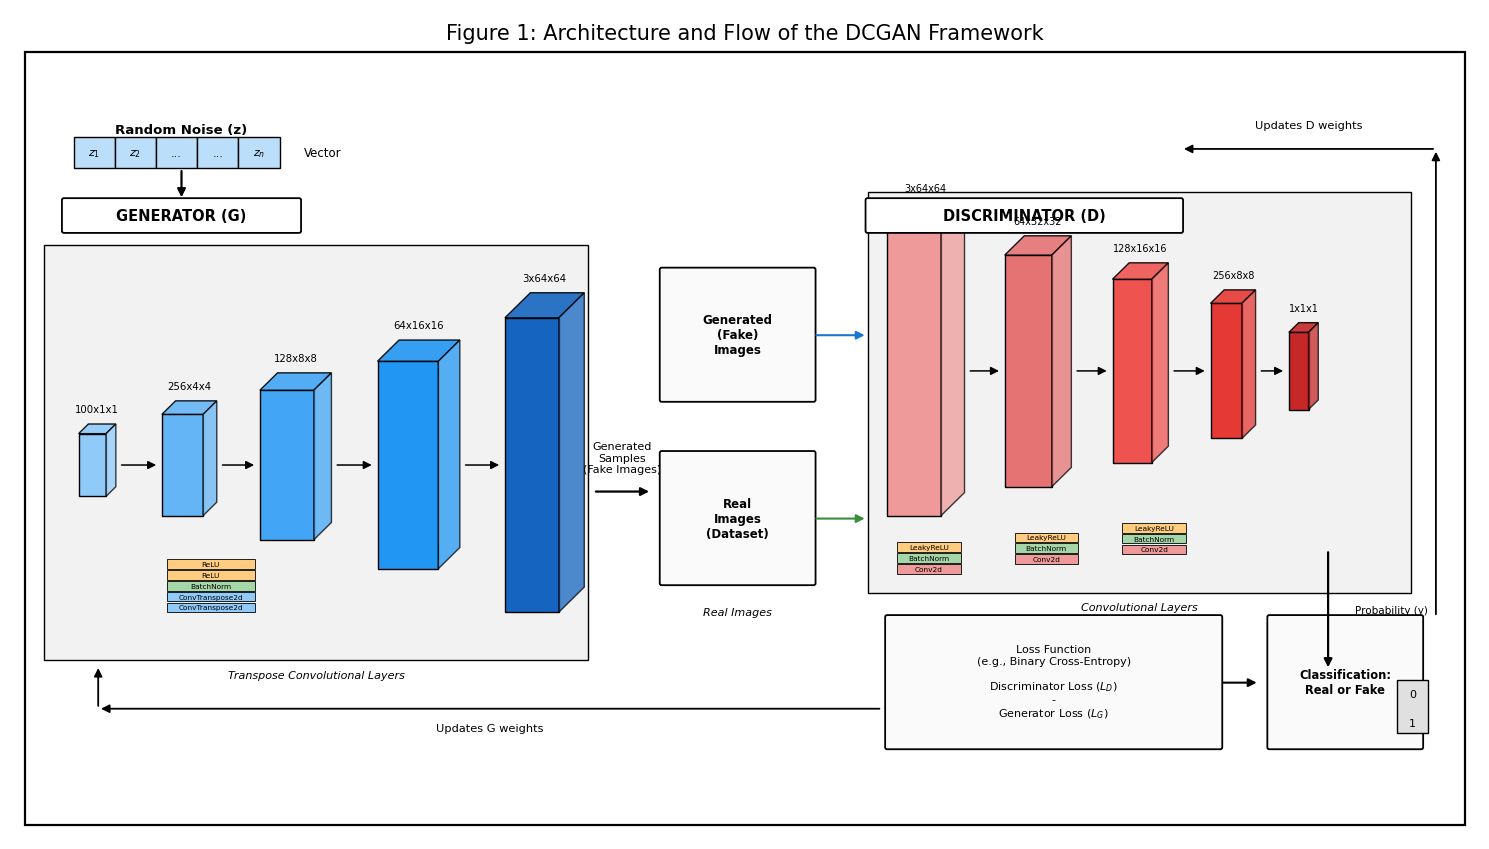

In [10]:
"""
DCGAN Architecture and Flow Diagram
Recreates a publication-style figure (isometric feature-map cuboids +
generator/discriminator/loss flow) using pure matplotlib.

Requirements: matplotlib (pip install matplotlib)
Output: dcgan_flow_diagram.png / .pdf / .eps
"""

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch, Rectangle, FancyBboxPatch
import matplotlib.lines as mlines

# ----------------------------------------------------------------------
# Helper drawing functions
# ----------------------------------------------------------------------

def draw_cuboid(ax, x, y, w, h, depth, facecolor="#BBDEFB", edgecolor="black",
                 lw=1.0, alpha=1.0, zorder=2):
    """
    Draw a simple isometric-looking cuboid (feature map block).
    (x, y) = bottom-left corner of the FRONT face.
    w, h   = width/height of the front face.
    depth  = amount of skew/offset used to fake the top & side faces.
    """
    # Front face
    front = Rectangle((x, y), w, h, facecolor=facecolor, edgecolor=edgecolor,
                       lw=lw, alpha=alpha, zorder=zorder)
    ax.add_patch(front)

    # Top face (parallelogram)
    top = patches.Polygon(
        [(x, y + h), (x + depth, y + h + depth),
         (x + w + depth, y + h + depth), (x + w, y + h)],
        closed=True, facecolor=facecolor, edgecolor=edgecolor, lw=lw,
        alpha=min(alpha, 0.9), zorder=zorder
    )
    ax.add_patch(top)

    # Side face (parallelogram) - slightly darker
    side = patches.Polygon(
        [(x + w, y), (x + w + depth, y + depth),
         (x + w + depth, y + h + depth), (x + w, y + h)],
        closed=True, facecolor=facecolor, edgecolor=edgecolor, lw=lw,
        alpha=min(alpha, 0.75), zorder=zorder
    )
    ax.add_patch(side)

    return x, y, w, h, depth  # bounding info for later positioning


def draw_layer_stack(ax, x, y, w, layers, layer_h=0.10, gap=0.012):
    """
    Draw a small vertical stack of thin colored bars representing
    sub-operations (ConvTranspose2d / BatchNorm / ReLU, etc.) attached
    to the first block of a pipeline, like in the reference figure.
    layers: list of (label, facecolor)
    """
    cur_y = y
    for label, color in layers:
        rect = Rectangle((x, cur_y), w, layer_h, facecolor=color,
                          edgecolor="black", lw=0.6, zorder=4)
        ax.add_patch(rect)
        ax.text(x + w / 2, cur_y + layer_h / 2, label, ha="center",
                 va="center", fontsize=5.3, zorder=5)
        cur_y += layer_h + gap
    return cur_y


def rounded_box(ax, x, y, w, h, text=None, facecolor="white",
                 edgecolor="black", lw=1.3, fontsize=9, fontweight="bold",
                 pad=0.02, zorder=3, textcolor="black"):
    box = FancyBboxPatch((x, y), w, h,
                          boxstyle=f"round,pad={pad},rounding_size=0.02",
                          facecolor=facecolor, edgecolor=edgecolor, lw=lw,
                          zorder=zorder)
    ax.add_patch(box)
    if text:
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
                 fontsize=fontsize, fontweight=fontweight, zorder=zorder + 1,
                 color=textcolor)
    return x, y, w, h


def panel_box(ax, x, y, w, h, label=None, facecolor="#F2F2F2",
              edgecolor="black", lw=1.0, zorder=0, label_pos="bottom"):
    box = Rectangle((x, y), w, h, facecolor=facecolor, edgecolor=edgecolor,
                     lw=lw, zorder=zorder)
    ax.add_patch(box)
    if label:
        ly = y - 0.15 if label_pos == "bottom" else y + h + 0.08
        ax.text(x + w / 2, ly, label, ha="center", va="center",
                 fontsize=8, style="italic", zorder=zorder + 1)
    return x, y, w, h


def arrow(ax, p1, p2, label=None, color="black", lw=1.4, style="-|>",
          connectionstyle="arc3,rad=0.0", fontsize=7.5, label_offset=(0, 0.1),
          zorder=6, ls="solid"):
    a = FancyArrowPatch(p1, p2, arrowstyle=style, mutation_scale=12,
                         color=color, lw=lw, connectionstyle=connectionstyle,
                         zorder=zorder, linestyle=ls)
    ax.add_patch(a)
    if label:
        mx, my = (p1[0] + p2[0]) / 2 + label_offset[0], (p1[1] + p2[1]) / 2 + label_offset[1]
        ax.text(mx, my, label, ha="center", va="center", fontsize=fontsize,
                 zorder=zorder + 1)


# ----------------------------------------------------------------------
# Figure setup
# ----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 8.6))
ax.set_xlim(0, 15)
ax.set_ylim(0, 8.6)
ax.axis("off")

# Outer border
outer = Rectangle((0.15, 0.15), 14.7, 8.0, facecolor="white",
                   edgecolor="black", lw=1.6, zorder=0)
ax.add_patch(outer)

ax.text(7.5, 8.35, "Figure 1: Architecture and Flow of the DCGAN Framework",
        ha="center", va="center", fontsize=15)

# ----------------------------------------------------------------------
# 1. Random noise vector z
# ----------------------------------------------------------------------

ax.text(1.75, 7.35, "Random Noise (z)", ha="center", va="center",
         fontsize=9.5, fontweight="bold")

z_labels = ["$z_1$", "$z_2$", "...", "...", "$z_n$"]
z_x0, z_y0, z_w, z_h = 0.65, 6.95, 0.42, 0.32
for i, lab in enumerate(z_labels):
    xx = z_x0 + i * z_w
    rect = Rectangle((xx, z_y0), z_w, z_h, facecolor="#BBDEFB",
                      edgecolor="black", lw=1.0, zorder=3)
    ax.add_patch(rect)
    ax.text(xx + z_w / 2, z_y0 + z_h / 2, lab, ha="center", va="center",
             fontsize=8, zorder=4)
ax.text(z_x0 + len(z_labels) * z_w + 0.25, z_y0 + z_h / 2, "Vector",
         ha="left", va="center", fontsize=8.5)

arrow(ax, (1.75, z_y0), (1.75, 6.62), lw=1.6)

# ----------------------------------------------------------------------
# 2. GENERATOR (G) header box
# ----------------------------------------------------------------------

rounded_box(ax, 0.55, 6.30, 2.4, 0.32, text="GENERATOR (G)",
            facecolor="white", fontsize=10.5)

# ----------------------------------------------------------------------
# 3. Generator panel with transpose-conv cuboid pipeline
# ----------------------------------------------------------------------

gen_panel = panel_box(ax, 0.35, 1.85, 5.55, 4.30, facecolor="#F2F2F2",
                       label="Transpose Convolutional Layers")

# Cuboid pipeline: sizes shrink in "depth label" but grow visually L->R
cuboid_specs = [
    # (x, y, w, h, depth, color, size_label)
    (0.70, 3.55, 0.28, 0.65, 0.10, "#90CAF9", "100x1x1"),
    (1.55, 3.35, 0.42, 1.05, 0.14, "#64B5F6", "256x4x4"),
    (2.55, 3.10, 0.55, 1.55, 0.18, "#42A5F5", "128x8x8"),
    (3.75, 2.80, 0.62, 2.15, 0.22, "#2196F3", "64x16x16"),
    (5.05, 2.35, 0.55, 3.05, 0.26, "#1565C0", "3x64x64"),
]
size_label_y_off = [0.85, 1.30, 1.85, 2.55, 3.45]

for (cx, cy, cw, ch, cd, ccolor, slabel), ylab in zip(cuboid_specs, size_label_y_off):
    draw_cuboid(ax, cx, cy, cw, ch, cd, facecolor=ccolor)
    ax.text(cx + cw / 2 + cd / 2, cy + ch + cd + 0.10, slabel,
             ha="center", va="bottom", fontsize=7.3)

# layer-stack legend attached to the 2nd cuboid (ConvTranspose2d/BN/ReLU)
layer_defs = [
    ("ConvTranspose2d", "#90CAF9"),
    ("ConvTranspose2d", "#90CAF9"),
    ("BatchNorm", "#A5D6A7"),
    ("ReLU", "#FFCC80"),
    ("ReLU", "#FFCC80"),
]
draw_layer_stack(ax, 1.60, 2.35, 0.9, layer_defs)

# connecting arrows between cuboids
for i in range(len(cuboid_specs) - 1):
    x1 = cuboid_specs[i][0] + cuboid_specs[i][2] + cuboid_specs[i][4]
    y1 = cuboid_specs[i][1] + cuboid_specs[i][3] / 2
    x2 = cuboid_specs[i + 1][0]
    y2 = cuboid_specs[i + 1][1] + cuboid_specs[i + 1][3] / 2
    arrow(ax, (x1 + 0.03, y1), (x2 - 0.03, y2), lw=1.1)

# ----------------------------------------------------------------------
# 4. Generated / Real image boxes -> Discriminator
# ----------------------------------------------------------------------

arrow(ax, (5.95, 3.6), (6.55, 3.6), lw=1.6)
ax.text(6.25, 3.95, "Generated\nSamples\n(Fake Images)", ha="center",
         va="center", fontsize=8)

fake_box = rounded_box(ax, 6.65, 4.55, 1.55, 1.35, text="Generated\n(Fake)\nImages",
                        facecolor="#FAFAFA", fontsize=8.5)
real_box = rounded_box(ax, 6.65, 2.65, 1.55, 1.35, text="Real\nImages\n(Dataset)",
                        facecolor="#FAFAFA", fontsize=8.5)
ax.text(7.42, 2.35, "Real Images", ha="center", va="center", fontsize=8,
         style="italic")

arrow(ax, (8.20, 5.22), (8.75, 5.22), color="#1976D2", lw=1.5)
arrow(ax, (8.20, 3.32), (8.75, 3.32), color="#388E3C", lw=1.5)

# ----------------------------------------------------------------------
# 5. DISCRIMINATOR (D)
# ----------------------------------------------------------------------

rounded_box(ax, 8.75, 6.30, 3.2, 0.32, text="DISCRIMINATOR (D)",
            facecolor="white", fontsize=10.5)

disc_panel = panel_box(ax, 8.75, 2.55, 5.55, 4.15, facecolor="#F2F2F2",
                        label="Convolutional Layers")

d_cuboid_specs = [
    (8.95, 3.35, 0.55, 3.00, 0.24, "#EF9A9A", "3x64x64"),
    (10.15, 3.65, 0.48, 2.40, 0.20, "#E57373", "64x32x32"),
    (11.25, 3.90, 0.40, 1.90, 0.17, "#EF5350", "128x16x16"),
    (12.25, 4.15, 0.32, 1.40, 0.14, "#E53935", "256x8x8"),
    (13.05, 4.45, 0.20, 0.80, 0.10, "#C62828", "1x1x1"),
]
for cx, cy, cw, ch, cd, ccolor, slabel in d_cuboid_specs:
    draw_cuboid(ax, cx, cy, cw, ch, cd, facecolor=ccolor)
    ax.text(cx + cw / 2 + cd / 2, cy + ch + cd + 0.10, slabel,
             ha="center", va="bottom", fontsize=7.0)

d_layer_defs = [
    ("Conv2d", "#EF9A9A"),
    ("BatchNorm", "#A5D6A7"),
    ("LeakyReLU", "#FFCC80"),
]
draw_layer_stack(ax, 9.05, 2.75, 0.65, d_layer_defs)
draw_layer_stack(ax, 10.25, 2.85, 0.65, d_layer_defs)
draw_layer_stack(ax, 11.35, 2.95, 0.65, d_layer_defs)

for i in range(len(d_cuboid_specs) - 1):
    x1 = d_cuboid_specs[i][0] + d_cuboid_specs[i][2] + d_cuboid_specs[i][4]
    y1 = d_cuboid_specs[i][1] + d_cuboid_specs[i][3] / 2
    x2 = d_cuboid_specs[i + 1][0]
    y2 = d_cuboid_specs[i + 1][1] + d_cuboid_specs[i + 1][3] / 2
    arrow(ax, (x1 + 0.03, y1), (x2 - 0.03, y2), lw=1.1)

# ----------------------------------------------------------------------
# 6. Probability -> Loss function -> Classification
# ----------------------------------------------------------------------

arrow(ax, (13.45, 3.0), (13.45, 1.75), label="Probability (y)",
      label_offset=(0.65, 0.0), lw=1.6)

loss_box = rounded_box(ax, 8.95, 0.95, 3.4, 1.35,
                        text="Loss Function\n(e.g., Binary Cross-Entropy)\n\n"
                             "Discriminator Loss ($L_D$)\n-\nGenerator Loss ($L_G$)",
                        facecolor="#FAFAFA", fontsize=8, fontweight="normal")

arrow(ax, (12.35, 1.62), (12.75, 1.62), lw=1.5)
class_box = rounded_box(ax, 12.85, 0.95, 1.55, 1.35,
                         text="Classification:\nReal or Fake",
                         facecolor="#FAFAFA", fontsize=8.3)
rect01 = Rectangle((14.15, 1.10), 0.32, 0.55, facecolor="#E0E0E0",
                    edgecolor="black", lw=1.0, zorder=4)
ax.add_patch(rect01)
ax.text(14.31, 1.50, "0", ha="center", va="center", fontsize=8, zorder=5)
ax.text(14.31, 1.20, "1", ha="center", va="center", fontsize=8, zorder=5)

# ----------------------------------------------------------------------
# 7. Feedback loops: Updates D weights / Updates G weights
# ----------------------------------------------------------------------

# Updates D weights: loss box -> up along the far right edge -> discriminator top
arrow(ax, (14.55, 2.30), (14.55, 7.15), color="black", lw=1.3)
arrow(ax, (14.55, 7.15), (11.95, 7.15), color="black", lw=1.3)
ax.text(13.25, 7.40, "Updates D weights", ha="center", va="center",
         fontsize=8.2)

# Updates G weights: loss box -> along bottom -> generator bottom
arrow(ax, (8.9, 1.35), (0.9, 1.35), color="black", lw=1.3)
arrow(ax, (0.9, 1.35), (0.9, 1.80), color="black", lw=1.3)
ax.text(4.9, 1.15, "Updates G weights", ha="center", va="center",
         fontsize=8.2)

plt.tight_layout()
plt.savefig("dcgan_flow_diagram.png", dpi=300, bbox_inches="tight")
plt.savefig("dcgan_flow_diagram.pdf", bbox_inches="tight")
plt.savefig("dcgan_flow_diagram.eps", bbox_inches="tight")
print("Diagram saved: dcgan_flow_diagram.png / .pdf / .eps")

In [6]:
import sys
import os

conda_bin = os.path.join(sys.prefix, "Library", "bin")
print("Your Graphviz Bin Path is:", conda_bin)
print("Does 'dot.exe' exist here?", os.path.exists(os.path.join(conda_bin, "dot.exe")))

Your Graphviz Bin Path is: c:\Users\sans\anaconda3\Library\bin
Does 'dot.exe' exist here? False


Diagram saved: dcgan_lsun_simple.png / .pdf / .eps


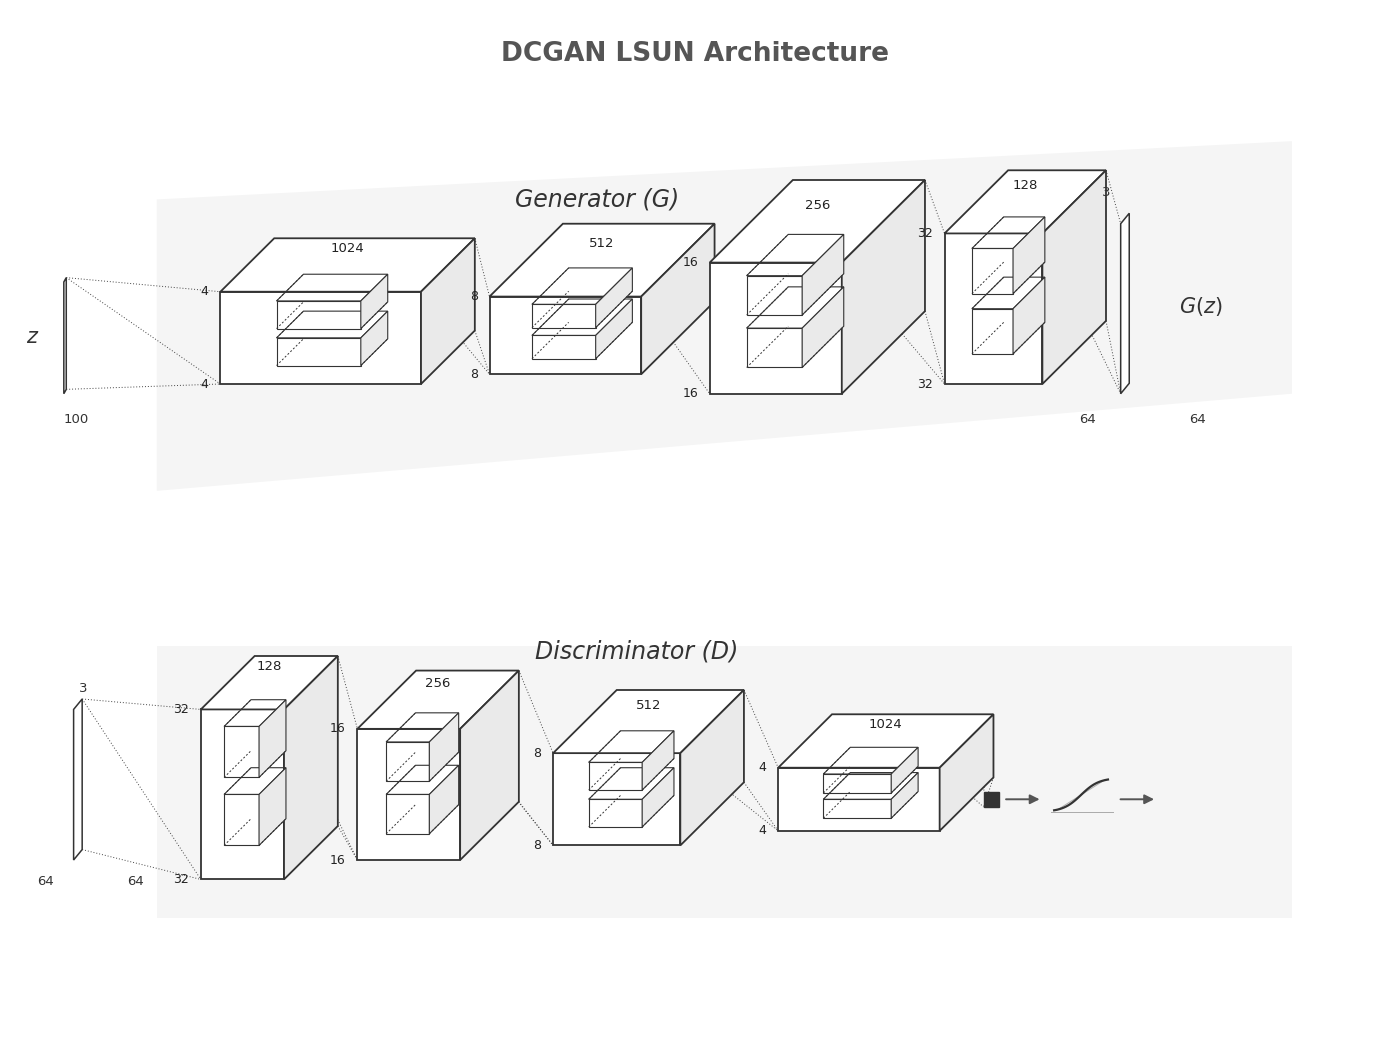

In [11]:
"""
DCGAN LSUN Architecture Diagram (classic Radford et al. style)
Pure matplotlib recreation: isometric cuboids with nested dashed
"receptive-field" insets, converging dotted connector lines,
teal Generator trapezoid + orange Discriminator trapezoid.

Requirements: matplotlib (pip install matplotlib)
Output: dcgan_lsun_simple.png / .pdf / .eps
"""

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon, Rectangle, FancyArrowPatch
import numpy as np

TEAL = "#333333"
TEAL_FILL = "#FFFFFF"
TEAL_BG = "#F5F5F5"
ORANGE = "#333333"
ORANGE_FILL = "#FFFFFF"
ORANGE_BG = "#F5F5F5"
RED = "#333333"
GRAY = "#333333"


def cuboid(ax, x, y, w, h, dx, dy, edgecolor, facecolor, lw=1.3, alpha=1.0,
           top_label=None, left_top_label=None, left_bottom_label=None,
           label_color="#222222"):
    """
    Draw an isometric cuboid.
    (x, y): bottom-left of the FRONT face.
    w, h  : front-face width/height.
    dx,dy : skew vector for the top/side (perspective) faces.
    Returns dict of key corner points for connecting lines.
    """
    # Front face corners
    fbl = (x, y)
    fbr = (x + w, y)
    ftl = (x, y + h)
    ftr = (x + w, y + h)

    # Back-shifted corners (top/side faces)
    bbl = (x + dx, y + dy)
    bbr = (x + w + dx, y + dy)
    btl = (x + dx, y + h + dy)
    btr = (x + w + dx, y + h + dy)

    front = Polygon([fbl, fbr, ftr, ftl], closed=True, facecolor=facecolor,
                     edgecolor=edgecolor, lw=lw, alpha=alpha, zorder=3)
    top = Polygon([ftl, ftr, btr, btl], closed=True, facecolor=facecolor,
                  edgecolor=edgecolor, lw=lw, alpha=alpha, zorder=3)
    side = Polygon([fbr, bbr, btr, ftr], closed=True, facecolor="#EAEAEA",
                   edgecolor=edgecolor, lw=lw, alpha=alpha, zorder=3)
    for p in (front, top, side):
        ax.add_patch(p)

    if top_label:
        ax.text((ftl[0] + btr[0]) / 2, (ftl[1] + btr[1]) / 2 + 0.10,
                 top_label, ha="center", va="bottom", fontsize=9.5,
                 color=label_color)
    if left_top_label:
        ax.text(x - 0.12, y + h, left_top_label, ha="right", va="center",
                 fontsize=9, color=label_color)
    if left_bottom_label:
        ax.text(x - 0.12, y, left_bottom_label, ha="right", va="center",
                 fontsize=9, color=label_color)

    return dict(fbl=fbl, fbr=fbr, ftl=ftl, ftr=ftr,
                bbl=bbl, bbr=bbr, btl=btl, btr=btr)


def inset_cuboid(ax, host, edgecolor, scale=0.42, offset=0.08):
    """Draw a small dashed 'receptive field' cuboid nested inside a host cuboid,
    roughly centred, echoing the reference figure's nested-cube motif."""
    x0, y0 = host["fbl"]
    w = host["fbr"][0] - host["fbl"][0]
    h = host["ftl"][1] - host["fbl"][1]
    dx = host["bbl"][0] - host["fbl"][0]
    dy = host["bbl"][1] - host["fbl"][1]

    sw, sh = w * scale, h * 0.30
    cx = x0 + w * 0.28
    cy_top = y0 + h * 0.60
    cy_bot = y0 + h * 0.20

    for cy in (cy_bot, cy_top):
        c = cuboid(ax, cx, cy, sw, sh, dx * 0.5, dy * 0.5,
                   edgecolor=edgecolor, facecolor="none", lw=0.8, alpha=1.0)
        # redraw hidden edges as dashed to hint transparency
        for a, b in [(c["fbl"], c["bbl"]), (c["fbr"], c["bbr"]),
                     (c["ftl"], c["btl"])]:
            ax.plot([a[0], b[0]], [a[1], b[1]], ls=(0, (2, 2)),
                     color=edgecolor, lw=0.7, zorder=3)


def converge(ax, host_a, host_b, color, lw=0.7):
    """Dotted perspective lines linking the back corners of box A to the
    front corners of box B (or plane B), mimicking a projection frustum."""
    pairs = [
        (host_a.get("btr", host_a.get("ftr")), host_b.get("ftl", host_b.get("fbl"))),
        (host_a.get("bbr", host_a.get("fbr")), host_b.get("fbl")),
        (host_a.get("btr", host_a.get("ftr")), host_b.get("ftl")),
        (host_a.get("ftr"), host_b.get("fbl")),
    ]
    seen = set()
    for a, b in pairs:
        if a is None or b is None:
            continue
        key = (a, b)
        if key in seen:
            continue
        seen.add(key)
        ax.plot([a[0], b[0]], [a[1], b[1]], ls=(0, (1, 2)), color=color,
                 lw=lw, zorder=2)


def plane(ax, x, y, w, h, dx, dy, edgecolor, facecolor, alpha=0.6, lw=1.1):
    """A thin flat 'image plane' (parallelogram slab), used for z, G(z), and
    the discriminator's input image."""
    fbl = (x, y)
    fbr = (x + dx * 0.25, y + dy * 0.25 + 0.02)
    ftl = (x, y + h)
    ftr = (x + dx * 0.25, y + h + dy * 0.25 + 0.02)
    poly = Polygon([fbl, fbr, ftr, ftl], closed=True, facecolor=facecolor,
                    edgecolor=edgecolor, lw=lw, alpha=alpha, zorder=3)
    ax.add_patch(poly)
    return dict(fbl=fbl, fbr=fbr, ftl=ftl, ftr=ftr,
                bbl=fbl, bbr=fbr, btl=ftl, btr=ftr)


# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10.5)
ax.axis("off")

ax.text(7, 10.05, "DCGAN LSUN Architecture", ha="center", va="center",
         fontsize=19, color="#555555", fontweight="bold")

# ======================================================================
# GENERATOR (top, teal)
# ======================================================================

gen_bg = Polygon([(1.5, 5.55), (13.1, 6.55), (13.1, 9.15), (1.5, 8.55)],
                  closed=True, facecolor=TEAL_BG, edgecolor="none", zorder=1)
ax.add_patch(gen_bg)
ax.text(6.0, 8.55, "Generator (G)", ha="center", va="center", fontsize=17,
         style="italic", color=TEAL)

# z vector (thin red slab)
z_plane = plane(ax, 0.55, 6.55, 0.28, 1.15, 0.10, 0.10,
                edgecolor=RED, facecolor="white", alpha=1.0)
ax.text(0.30, 7.13, "$z$", ha="right", va="center", fontsize=15, color=RED,
         style="italic")
ax.text(0.68, 6.35, "100", ha="center", va="top", fontsize=9.5, color=GRAY)

# Generator cuboids: (x, y, w, h, dx, dy, top_label, size_top, size_bottom)
g_specs = [
    (2.15, 6.65, 2.05, 0.95, 0.55, 0.55, "1024", "4", "4"),
    (4.90, 6.75, 1.55, 0.80, 0.75, 0.75, "512", "8", "8"),
    (7.15, 6.55, 1.35, 1.35, 0.85, 0.85, "256", "16", "16"),
    (9.55, 6.65, 1.00, 1.55, 0.65, 0.65, "128", "32", "32"),
]

g_hosts = [z_plane]
for x, y, w, h, dx, dy, top, sl_top, sl_bot in g_specs:
    host = cuboid(ax, x, y, w, h, dx, dy, edgecolor=TEAL, facecolor=TEAL_FILL,
                  top_label=top, left_top_label=sl_top,
                  left_bottom_label=sl_bot)
    inset_cuboid(ax, host, edgecolor=TEAL)
    g_hosts.append(host)

# G(z) output plane
gz_plane = plane(ax, 11.35, 6.55, 0.30, 1.75, 0.35, 0.35,
                  edgecolor=TEAL, facecolor="white", alpha=1.0)
ax.text(11.20, 8.55, "3", ha="center", va="bottom", fontsize=9.5, color=GRAY)
ax.text(11.95, 7.45, "$G(z)$", ha="left", va="center", fontsize=15,
         color=TEAL, style="italic")
ax.text(12.05, 6.35, "64", ha="left", va="top", fontsize=9.5, color=GRAY)
ax.text(11.10, 6.35, "64", ha="right", va="top", fontsize=9.5, color=GRAY)
g_hosts.append(gz_plane)

for a, b in zip(g_hosts[:-1], g_hosts[1:]):
    converge(ax, a, b, color="#444444")

# ======================================================================
# DISCRIMINATOR (bottom, orange) — mirrors the generator
# ======================================================================

disc_bg = Polygon([(1.5, 1.15), (13.1, 1.15), (13.1, 3.95), (1.5, 3.95)],
                   closed=True, facecolor=ORANGE_BG, edgecolor="none", zorder=1)
ax.add_patch(disc_bg)
ax.text(6.4, 3.90, "Discriminator (D)", ha="center", va="center",
         fontsize=17, style="italic", color=ORANGE)

# Input image plane
img_plane = plane(ax, 0.65, 1.75, 0.30, 1.55, 0.35, 0.35,
                   edgecolor=ORANGE, facecolor="white", alpha=1.0)
ax.text(0.75, 3.45, "3", ha="center", va="bottom", fontsize=9.5, color=GRAY)
ax.text(0.45, 1.60, "64", ha="right", va="top", fontsize=9.5, color=GRAY)
ax.text(1.20, 1.60, "64", ha="left", va="top", fontsize=9.5, color=GRAY)

d_specs = [
    (1.95, 1.55, 0.85, 1.75, 0.55, 0.55, "128", "32", "32"),
    (3.55, 1.75, 1.05, 1.35, 0.60, 0.60, "256", "16", "16"),
    (5.55, 1.90, 1.30, 0.95, 0.65, 0.65, "512", "8", "8"),
    (7.85, 2.05, 1.65, 0.65, 0.55, 0.55, "1024", "4", "4"),
]

d_hosts = [img_plane]
for x, y, w, h, dx, dy, top, sl_top, sl_bot in d_specs:
    host = cuboid(ax, x, y, w, h, dx, dy, edgecolor=ORANGE,
                  facecolor=ORANGE_FILL, top_label=top,
                  left_top_label=sl_top, left_bottom_label=sl_bot)
    inset_cuboid(ax, host, edgecolor=ORANGE)
    d_hosts.append(host)

for a, b in zip(d_hosts[:-1], d_hosts[1:]):
    converge(ax, a, b, color="#444444")

# Small terminal square + sigmoid glyph + output arrows
last = d_hosts[-1]
sq_x = last["fbr"][0] + 0.45
sq_y = (last["fbl"][1] + last["ftl"][1]) / 2 - 0.08
sq = Rectangle((sq_x, sq_y), 0.16, 0.16, facecolor=ORANGE, edgecolor=ORANGE,
               zorder=3)
ax.add_patch(sq)
converge(ax, last, dict(fbl=(sq_x, sq_y), ftl=(sq_x, sq_y + 0.16)),
         color="#444444")

arr1 = FancyArrowPatch((sq_x + 0.20, sq_y + 0.08), (sq_x + 0.60, sq_y + 0.08),
                        arrowstyle="-|>", mutation_scale=14, color="#555555",
                        lw=1.4, zorder=4)
ax.add_patch(arr1)

# sigmoid curve glyph
sx0 = sq_x + 0.72
t = np.linspace(-3, 3, 60)
sig = 1 / (1 + np.exp(-t))
ax.plot(sx0 + (t + 3) / 6 * 0.55, sq_y - 0.05 + sig * 0.35, color="#333333",
         lw=1.6, zorder=4)
ax.annotate("", xy=(sx0 + 0.55, sq_y + 0.30), xytext=(sx0, sq_y - 0.05),
            arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.7),
            zorder=3)
ax.plot([sx0 - 0.03, sx0 + 0.60], [sq_y - 0.05, sq_y - 0.05], color="#AAAAAA",
         lw=0.7, zorder=3)

arr2 = FancyArrowPatch((sx0 + 0.65, sq_y + 0.08), (sx0 + 1.05, sq_y + 0.08),
                        arrowstyle="-|>", mutation_scale=14, color="#555555",
                        lw=1.4, zorder=4)
ax.add_patch(arr2)

plt.tight_layout()
plt.savefig("dcgan_lsun_simple.png", dpi=300, bbox_inches="tight")
plt.savefig("dcgan_lsun_simple.pdf", bbox_inches="tight")
plt.savefig("dcgan_lsun_simple.eps", bbox_inches="tight")
print("Diagram saved: dcgan_lsun_simple.png / .pdf / .eps")